## **SUMMARY**
This script is used to create a footprint-level inventory using all local and national data sources from Hayward.

Steps include selecting values for features with disagreement, filling gaps in the data, and mapping to the features required to simulation. 


In [1]:
# Copyright (c) 2025, Meredith Lochhead
# All rights reserved.
#
# This source code is licensed under the BSD 3-Clause License found in the
# LICENSE file in the root directory of this source tree.

In [2]:
## NOTE: In order to run this script, a Census API Key is needed
# A Census API Key can be requested at https://www.census.gov/data/developers/about/terms-of-service.html for free by clicking the 'Request a key' banner

# # Option 1: Copy and paste API Key directly
# census_api_key = ""

# Option 2: Import API Key from .txt file
with open("./Input_Data/Census/census_api_key.txt", "r", encoding="utf-8") as file:
    census_api_key = file.read()

In [3]:
# Relevant python functions
import numpy as np
import pandas as pd
import geopandas as gpd
import random
import matplotlib.pyplot as plt
import folium 
import contextily as ctx
import os
import sys
from shapely import wkt
import requests

from shapely.geometry import box
from matplotlib.ticker import ScalarFormatter, MaxNLocator
import matplotlib.patches as mpatches

# BRAILS functions for imputation 
from brails.types.image_set import ImageSet    
from brails.types.asset_inventory import Asset, AssetInventory
from brails.utils import Importer

# Import functions for inventory generation 
parent_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))
fxn_dir = os.path.join(parent_dir, "inventory_generation_functions")
sys.path.append(fxn_dir)

import functions_general as fxns
import functions_disagreement_and_gaps as resolve
import functions_national_preprocessing as pre # Used here only to assign HIFLD Mobile Home data to census blocks 

In [4]:
# Set plotting CRS values for data manipulation and plotting
crs_main = '26910' # Used for data manipulation and storage
crs_plot = '4269' # Used for plotting 

# HAYWARD BOUNDS
xbounds = [-122.15, -122.02]
ybounds = [37.60, 37.69]

# Set state, state fips, and county for download
state = 'California'
state_fips = '06'
county = 'Alameda'
county_fips = '001'

In [5]:
# Target Directory 
directory = './Inventory_Outputs/Best_Estimate/'
name = 'Best_Estimate' 

# Make directory and intermediate directory
os.makedirs(directory, exist_ok=True)
dir_generation = directory + 'InventoryGeneration/'
dir_r2d = './R2D_Analysis/Inventories/' + name + '/'
os.makedirs(dir_generation, exist_ok=True)
os.makedirs(dir_r2d, exist_ok=True)

# Figure Directory 
fig_dir = './Figures/General/'
os.makedirs(fig_dir, exist_ok=True)


In [6]:
## Set flag to plot data sources for each feature
plot_sources = True 

## **Select Values for Features with Disagreement**

In [7]:
# Load AppropriateData
national = fxns.json_to_gdf(directory + 'FootprintAttribution/National_Inventory_Final.json', crs_main)
local = fxns.json_to_gdf('./Inventory_Outputs/Synthesized_Local/FootprintAttribution/All_Local_Data_Attributed.json', crs_main)
footprints = fxns.json_to_gdf('./Input_Data/ProcessedFootprints/Hayward_Footprints.json', crs_main)
footprints_aug = fxns.json_to_gdf('./Input_Data/ProcessedFootprints/Hayward_Footprints_AUGMENTED.json', crs_main)

# Drop columns that are shared between sources 
local = local.drop(columns = ['geometry', 'ftpt_geometry', 'FootprintArea', 'FootprintHeight', 'CensusBlock', 'CensusTract', 'Footprint_Flag'])

# Merge Data based on FootprintID and check no data is lost
inv_raw = gpd.GeoDataFrame(national.merge(local, on='FootprintID', how='outer', suffixes=['_national','_local']))
inv_raw['Local_Flag'] = inv_raw['Local_Flag'].fillna(0)
inv_raw['National_Flag'] = inv_raw['National_Flag'].fillna(0)
if len(footprints_aug) != len(inv_raw): 
    raise ValueError('Footprint data lost in merge')


# Create modifiable instance of raw inventory 
inv_mod = inv_raw.copy()

In [8]:
# ### UNCOMMENT CODE TO PLOT INTERACTIVE MAP WITH FOOTPRINTS AND NSI POINTS

# # Create a base map
# m = folium.Map(location=[footprints.copy().to_crs(crs_plot).geometry.iloc[0].centroid.y, footprints.copy().to_crs(crs_plot).geometry.iloc[0].centroid.x], zoom_start=12)

# # Add footprints (polygons)
# folium.GeoJson(footprints.copy().to_crs(crs_plot), color = 'gray').add_to(m)

# # Add remaining points     
# for idx, row in inv_raw.copy().to_crs(crs_plot).iterrows():
#     folium.CircleMarker(location=[row.geometry.y, row.geometry.x], 
#                         radius=1, 
#                         color='blue', 
#                         fill=True, 
#                         fill_color='blue',
#                         popup = row[['National_Flag','Local_Flag']]).add_to(m)

# display(m)

### **Within-Source Disagreement for National Data Sources**

In [9]:
## RESOLVE WITHIN-SOURCE DISAGREEMENT (MINIMAL BETWEEN SOURCE DISAGREEMENT DUE TO USE OF ONlY NATIONAL DATASETS)

# Columns that are modified to a single value (down from a list) by selecting mode 
modified_to_single_solo = ['NSI_BuildingType', 'NSI_MedYearBuilt', 'NSI_NumberOfStories', 'NSI_TotalAreaSqFt']
for col in modified_to_single_solo:
    inv_mod[col + '_Single'] = inv_mod[col].apply(resolve.modify_to_single_val)

# Assign paired selections for foundation type and height 
# These variables, since they are directly related, will always be taken from the same original data point
inv_mod[['NSI_FoundationType_Single', 'NSI_FoundationHeight_Single']] = inv_mod[['NSI_FoundationType', 'NSI_FoundationHeight']].apply(resolve.modify_to_single_val_paired, axis=1).apply(pd.Series)

# Update occupancy class based on rulesets specific for NSI/HIFLD Occupancy Class 
inv_mod[['NSI_OccupancyClass_Single', 'NSI_OccupancyClass_MixedUse']] = inv_mod['NSI_OccupancyClass'].apply(resolve.modify_to_single_nsi_occupancy).apply(pd.Series)
inv_mod['NSI_OccupancyClass_Single'] = inv_mod['NSI_OccupancyClass_Single'].fillna('')


### **Within-Source Disagreement for Local Data Sources**

In [10]:
# Load Zoning Data to be used as prioritization method -- SAME CODE AS LOCAL INVENTORY GENERATION SCRIPT 
zoning = gpd.read_file('./Input_Data/Local/Hayward_Zoning.geojson')
zoning = zoning.to_crs(crs_main)
zoning = zoning[['ZONING_REPORT','ZONING_','ZONING_DETAIL','PD_Type','geometry']]

# Join with merged tax/NSI inventory 
inventory_zoning = inv_mod.sjoin(zoning, how='left')
inventory_zoning = inventory_zoning.drop_duplicates(subset=["FootprintID"], keep = 'first')
inventory_zoning = inventory_zoning.drop(columns = 'index_right')
inv_mod = inventory_zoning.copy()

In [11]:
# COLUMNS THAT ARE MODIFIED TO HAVE A SINGLE VALUE RATHER THAN A LIST  
modified_to_single_solo = ['Parcel_NumStories', 'Parcel_BldgArea'] 
for col in modified_to_single_solo:
    inv_mod[col + '_Single']  = inv_mod[col].apply(resolve.modify_to_single_val)

# Assign paired selections for building class and construction 
inv_mod[['Parcel_BldgClass_Single', 'Parcel_Construction_Single']] = inv_mod[['Parcel_BldgClass', 'Parcel_Construction_Hazus']].apply(resolve.modify_to_single_val_paired, axis=1).apply(pd.Series)

# Assign paired selections for year built and effective year built 
inv_mod[['Parcel_YearBuilt_Single', 'Parcel_EffYearBuilt_Single']] = inv_mod[['Parcel_YearBuilt', 'Parcel_EffYearBuilt']].apply(resolve.modify_to_single_val_paired, axis=1).apply(pd.Series)

# Apply function to map occupancy class values
inv_mod['Parcel_UseDescription_Hazus_Single'] = inv_mod[['Parcel_UseDescription_Hazus','ZONING_REPORT']].apply(resolve.modify_to_single_tax_occupancy, axis = 1)
inv_mod['Address_FeatureCode_Hazus_Single'] = inv_mod[['Address_FeatureCode_Hazus','ZONING_REPORT']].apply(resolve.modify_to_single_tax_occupancy, axis = 1)
    

In [12]:
## SAVE INVENTORY
fxns.gdf_to_json(inv_mod, dir_generation + 'Intra_Source_Resolved.json')

JSON File Saved


### **Between-Source Disagreement**

#### YEAR BUILT

Year Built Priority List: 

1. Effective year built (with unreasonable values screened out) - assumed to be most reflective of seismic performace
2. Year built (with unreasonable values screened out)
3. NSI median year built, which is constant across a census block

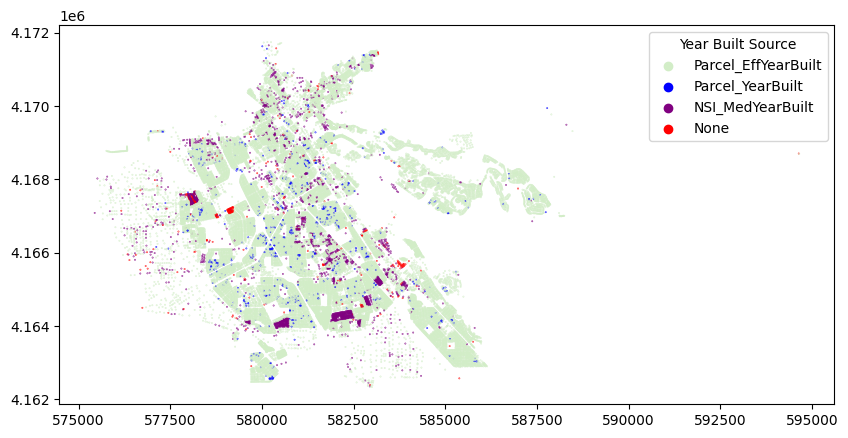

In [13]:
# Create combined row with best estimate of year built 
inv_mod['Year_Best'] = inv_mod.apply(
    lambda row: row['Parcel_EffYearBuilt_Single'] if pd.notna(row['Parcel_EffYearBuilt_Single']) 
    else (row['Parcel_YearBuilt_Single'] if pd.notna(row['Parcel_YearBuilt_Single']) 
    else (row['NSI_MedYearBuilt_Single'] if pd.notna(row['NSI_MedYearBuilt_Single']) 
    else np.nan)), axis=1)

# Create combined row with source of best estimate year 
inv_mod['Year_Best_Source'] = inv_mod.apply(
    lambda row: 'Parcel_EffYearBuilt' if pd.notna(row['Parcel_EffYearBuilt_Single']) 
        else ('Parcel_YearBuilt' if pd.notna(row['Parcel_YearBuilt_Single']) 
        else ('NSI_MedYearBuilt' if pd.notna(row['NSI_MedYearBuilt_Single']) 
        else 'None')), axis=1)



## PLOT INFORMATION SOURCE 
if plot_sources: 
    
    # Filter only for footprints with local data 
    inv_mod2 = inv_mod[~((inv_mod['Local_Flag']==0))].copy()

    # Define a color map for given field 
    unique_values = ['Parcel_EffYearBuilt', 'Parcel_YearBuilt', 'NSI_MedYearBuilt', 'None']
    color_map = {value: color for value, color in zip(unique_values, ['#d2edc7', 'blue', 'purple', 'red'])}
    inv_mod2['color'] = inv_mod2['Year_Best_Source'].map(color_map)

    # Plot 
    fig, ax = plt.subplots(figsize=(10, 8))
    inv_mod2.plot(ax=ax, color=inv_mod2['color'], markersize = .1)
    for value, color in color_map.items():
        ax.scatter([], [], color=color, label=value)
    ax.legend(title='Year Built Source')
    plt.show()


#### INCORPORATION OF MANUAL RES2 POLYGONS INTO NATIONAL DATA

In [14]:
# Load HIFLD Mobile Home Points in Area of Interest
mobile_all = gpd.read_file('./Input_Data/HIFLD/Mobile_Home_Parks.geojson')

# Convert Coordinates
mobile_all = mobile_all.to_crs(epsg=crs_main)

# Assign Census Block and Tract to HIFLD Data
hayward_blocks = gpd.read_file('./Input_Data/Census/Census2010/Hayward_blocks.geojson')
hayward_tracts = gpd.read_file('./Input_Data/Census/Census2010/Hayward_tracts.geojson')
mobile = pre.assign_census_hifld(mobile_all, hayward_blocks, hayward_tracts)


# Convert  MH Hayward file geometry to WKT and save as CSV (can be imported)
os.makedirs('./Input_Data/MH_Manual/', exist_ok=True)
mobile.to_crs(crs_plot).assign(geometry_wkt=mobile.to_crs(crs_plot).geometry.apply(wkt.dumps)) \
      .drop(columns='geometry') \
      .to_csv('./Input_Data/MH_Manual/Hayward_MH.csv', index=False)


### USE MANUALLY GENERATED POLYGONS TO FORCE RES2 OCCUPANCY
mh_polygons = gpd.read_file('./Input_Data/MH_Manual/MH_Hayward_Manual_Polygons.csv')
mh_polygons.set_crs(crs_plot, inplace = True)
mh_polygons.to_crs(crs_main, inplace = True)

# Find inventory points that are within RES2 polygons and reset 
in_polygons = gpd.sjoin(inv_mod, mh_polygons)
inv_mod.loc[in_polygons.index, 'NSI_OccupancyClass_Single'] = 'RES2'
inv_mod.loc[in_polygons.index, 'National_Flag'] = 1

# Modify so RES2 are all single unit, single story structures (assumed based on spot checking google maps) 
inv_mod.loc[in_polygons.index, 'NSI_MinResUnits'] = 1
inv_mod.loc[in_polygons.index, 'NSI_MaxResUnits'] = 1
inv_mod.loc[in_polygons.index, 'NSI_NumberOfStories_Single'] = 1

#### NUMBER OF STORIES

1. Tax number of stories is prioritized 
2. NSI number of stories -- occasionally there are very high values in this data. Based on spot checking, it appears less reliable at the footprint level 

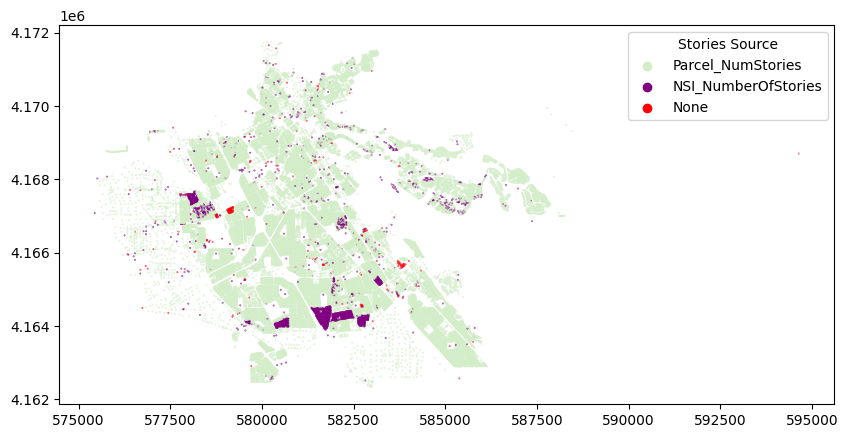

In [15]:
# Remove cases in tax or NSI data where number of stories is listed as 0
inv_mod.loc[inv_mod[inv_mod['Parcel_NumStories_Single'] == 0].index, 'Parcel_NumStories_Single'] = np.nan
inv_mod.loc[inv_mod[inv_mod['NSI_NumberOfStories_Single'] == 0].index, 'NSI_NumberOfStories_Single'] = np.nan

# Correct tax data type of 1.4 stories
inv_mod.loc[inv_mod[inv_mod['Parcel_NumStories'] == 1.4].index, 'Parcel_NumStories'] = 1.5

# Remove cases where NSI data says there are 15 or more stories (in case of Hayward, really no high rise buildings)
inv_mod.loc[inv_mod[inv_mod['NSI_NumberOfStories_Single'] >= 15].index, 'NSI_NumberOfStories_Single'] = np.nan

# Create combined row with best estimate of year built 
inv_mod['Stories_Best'] = inv_mod.apply(
    lambda row: row['Parcel_NumStories_Single'] if pd.notna(row['Parcel_NumStories_Single']) 
    else (row['NSI_NumberOfStories_Single'] if pd.notna(row['NSI_NumberOfStories_Single']) 
    else (np.nan)), axis=1)

# Create combined row with source of best estimate year 
inv_mod['Stories_Best_Source'] = inv_mod.apply(
    lambda row: 'Parcel_NumStories' if pd.notna(row['Parcel_NumStories_Single']) 
        else ('NSI_NumberOfStories' if pd.notna(row['NSI_NumberOfStories_Single']) 
        else ('None')), axis=1)



## PLOT INFORMATION SOURCE 
if plot_sources: 
    
    # Filter only for footprints with local data 
    inv_mod2 = inv_mod[~((inv_mod['Local_Flag']==0))].copy()

    # Define a color map for given field 
    unique_values = ['Parcel_NumStories', 'NSI_NumberOfStories', 'None']
    color_map = {value: color for value, color in zip(unique_values, ['#d2edc7', 'purple', 'red'])}
    inv_mod2['color'] = inv_mod2['Stories_Best_Source'].map(color_map)

    # Plot 
    fig, ax = plt.subplots(figsize=(10, 8))
    inv_mod2.plot(ax=ax, color=inv_mod2['color'], markersize = .1)
    for value, color in color_map.items():
        ax.scatter([], [], color=color, label=value)
    ax.legend(title='Stories Source') 
    plt.show()



#### NUMBER OF UNITS

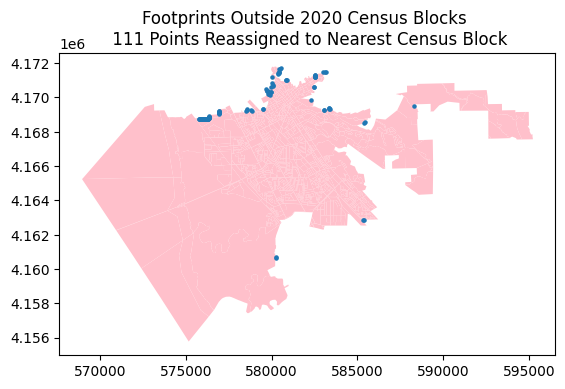

In [16]:
## LINK TO 2020 CENSUS BLOCKS TO ENABLE UNIT SCALING BASED ON DECENNIAL CENSUS DATA 

# Load footprint-based inventory and 2020 Census Blocks 
inventory = inv_mod.copy()
inv_length = len(inventory)
hayward_blocks20 = gpd.read_file('./Input_Data/Census/Census2020/Hayward_blocks.geojson')

# Find corresponding 2020 Census Block 
inventory = inventory.sjoin(hayward_blocks20[['GEOID20','geometry']], how='left')
inventory = inventory.rename(columns = {'GEOID20':'CensusBlock_2020'})

# Filter inventory for footprints with NSI points 
inventory0 = inventory[inventory['National_Flag']==0]
inventory = inventory[inventory['National_Flag']==1]

# Filter inventory for footprints that are outside vs inside 2020 census blocks 
inventory_outside2020blocks = inventory[inventory['CensusBlock_2020'].isna()].copy()

# Plot points
fig, ax = plt.subplots()
hayward_blocks20.plot(ax=ax, color='pink')
inventory_outside2020blocks.plot(ax=ax, markersize = 5)
ax.set_title(f'Footprints Outside 2020 Census Blocks \n {len(inventory_outside2020blocks)} Points Reassigned to Nearest Census Block')
plt.show()

# Assign footprints outside of census block to nearest census block 
inventory_outside2020blocks['Nearest'] = inventory_outside2020blocks['geometry'].apply(lambda point: resolve.outside_ftpt_nearest_cb(point, hayward_blocks20.to_crs(crs_main)[['GEOID20','geometry']]))
inventory.loc[inventory_outside2020blocks.index, 'CensusBlock_2020'] = inventory_outside2020blocks['Nearest'].values


In [17]:
### DOWNLOAD POPULATION AND NUMBER OF UNITS FOR 2020 CENSUS BLOCKS
cbs = resolve.download_census_data(census_api_key, hayward_blocks20, state_fips, county_fips)

## PLOT TO MAKE SURE DATA DOWNLOADED FOR CORRECT CENSUS BLOCKS 
merged = cbs.merge(hayward_blocks20, left_on='cb_code', right_on = 'GEOID20')
census_gdf = gpd.GeoDataFrame(merged, geometry=hayward_blocks20.geometry, crs=hayward_blocks20.crs)
fig, ax = plt.subplots(1, 2, figsize = (15, 5), sharex = True, sharey = True)
census_gdf.to_crs(crs_plot).plot(ax =ax[0], column='POP', cmap='viridis', legend=True, vmin = 0, vmax = 400)
census_gdf.to_crs(crs_plot).plot(ax = ax[1], column='UNITS', cmap='viridis', legend=True, vmin = 0, vmax = 200)
ax[0].set_title('POPULATION')
ax[1].set_title('UNITS')
ax[0].set_xlim(xbounds)
ax[0].set_ylim(ybounds)
plt.show()


ConnectionError: HTTPSConnectionPool(host='api.census.gov', port=443): Max retries exceeded with url: /data/2020/dec/pl?get=NAME%2CP1_001N%2CH1_001N%2CH1_002N&for=block%3A%2A&in=state%3A06+county%3A001&key=1983cc11d294711e939f42656c183836903a0370 (Caused by NameResolutionError("<urllib3.connection.HTTPSConnection object at 0x120f3eb60>: Failed to resolve 'api.census.gov' ([Errno 8] nodename nor servname provided, or not known)"))

In [ ]:
### ESTIMATE THE NUMBER OF UNITS USING CENSUS INFORMATION AND WITH POPULATION SCALING ###

# Pre-set modification flag to be 0
inventory['Flag_ModifiedByCensus'] = 0
inventory0['Flag_ModifiedByCensus'] = 0

# Assign number of units using information from census block 
inventory2 = resolve.assign_units_from_censusblock(inventory.copy(), 'CensusBlock_2020', cbs)

# Re-combine updated inventory with footprints with no NSI points 
inventory = resolve.recombine_dropped_data(inventory2, inventory0, inv_length)

# Drop appropriate columns 
inventory = inventory.drop(columns = ['index_right','CensusBlock_2020'])
inv_mod = inventory.copy()

Number of Units Priority List: 

1. Number of address points in a building footprint - based on spot checking and observations in Hayward, this is the most robust way to determine number of units 
2. Tax Parcel number of units - these sometimes get split/combined across and within footprints, so are slightly less preferred
3. Units scaled using 2020 Census data (Units_CensusEstimate)
4. Minimum residential units from NSI points (NSI_MinResUnits) -- this fills in RES values that are not assigned via census scaling. This incldues RES1 (1 unit), RES2 (1 unit), and RES3A (2 units)

In [ ]:
# Remove cases in tax data where number of address points is listed as 0
inv_mod.loc[inv_mod[inv_mod['Address_NumPoints'] == 0].index, 'Address_NumPoints'] = np.nan
inv_mod.loc[inv_mod[inv_mod['Parcel_NumUnits'] == 0].index, 'Parcel_NumUnits'] = np.nan
inv_mod.loc[inv_mod[inv_mod['Units_CensusEstimate'] == 0].index, 'Units_CensusEstimate'] = np.nan
inv_mod.loc[inv_mod[inv_mod['Units_CensusEstimate'] == 'None'].index, 'Units_CensusEstimate'] = np.nan

# Create combined row with best estimate of number of units 
inv_mod['Units_Best'] = inv_mod.apply(
    lambda row: row['Address_NumPoints'] if pd.notna(row['Address_NumPoints']) 
    else (row['Parcel_NumUnits'] if pd.notna(row['Parcel_NumUnits']) 
    else (row['Units_CensusEstimate'] if pd.notna(row['Units_CensusEstimate']) 
    else (row['NSI_MinResUnits'] if pd.notna(row['NSI_MinResUnits'])
    else np.nan))), axis=1)

# Create combined row with best estimate of number of units source
inv_mod['Units_Best_Source'] = inv_mod.apply(
    lambda row: 'Address_NumPoints' if pd.notna(row['Address_NumPoints']) 
    else ('Parcel_NumUnits' if pd.notna(row['Parcel_NumUnits']) 
    else ('Units_CensusEstimate' if pd.notna(row['Units_CensusEstimate']) 
    else ('NSI_MinResUnits' if pd.notna(row['NSI_MinResUnits'])
    else ('None')))), axis=1)


## PLOT INFORMATION SOURCE 
if plot_sources: 
    
    # Filter only for footprints with local data 
    inv_mod2 = inv_mod[~((inv_mod['Local_Flag']==0))].copy()

    # Define a color map for given field 
    unique_values = ['Address_NumPoints', 'Parcel_NumUnits', 'Units_CensusEstimate', 'NSI_MinResUnits','None']
    color_map = {value: color for value, color in zip(unique_values, ['#d2edc7', 'blue', 'purple', 'orange', 'red'])}
    inv_mod2['color'] = inv_mod2['Units_Best_Source'].map(color_map)

    # Plot 
    fig, ax = plt.subplots(figsize=(10, 8))
    inv_mod2.plot(ax=ax, color=inv_mod2['color'], markersize = .1)
    for value, color in color_map.items():
        ax.scatter([], [], color=color, label=value)
    ax.legend(title='Units Source') 
    plt.show()



KeyError: 'Units_CensusEstimate'

#### PLAN AREA

Plan Area Priority List: 

1. Tax Building Area divided by number of stories 
1. NSI Total Area SqFt divided by number of stories 
2. FootprintArea computed off footprint geometry


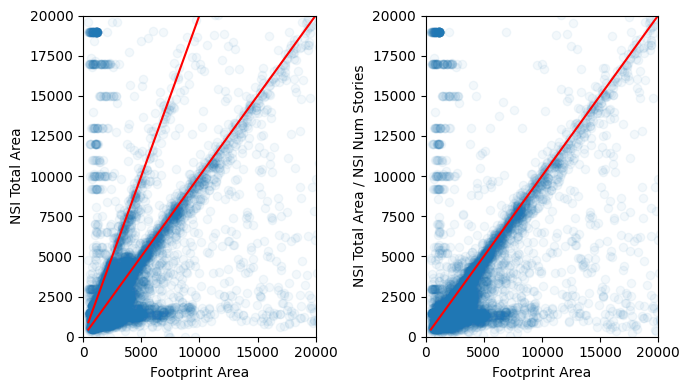

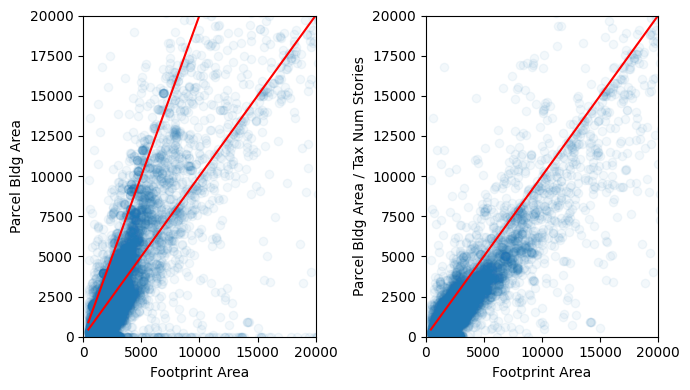

In [18]:
# PLOT TO ASSESS COMPARISON 

x_vals = np.linspace(min(inv_mod['FootprintArea']), max(inv_mod['FootprintArea']), 100)

fig, ax = plt.subplots(1,2, figsize = (7,4))
correlation = np.corrcoef(inv_mod[inv_mod['FootprintArea'].notna() & inv_mod['NSI_TotalAreaSqFt_Single'].notna()]['FootprintArea'], inv_mod[inv_mod['FootprintArea'].notna() & inv_mod['NSI_TotalAreaSqFt_Single'].notna()]['NSI_TotalAreaSqFt_Single'])[0, 1]
ax[0].scatter(inv_mod['FootprintArea'], inv_mod['NSI_TotalAreaSqFt_Single'], alpha = 0.05)
ax[0].set_xlim([0,20000])
ax[0].set_ylim([0,20000])
ax[0].set_ylabel('NSI Total Area')
ax[0].set_xlabel('Footprint Area')
ax[0].plot(x_vals, x_vals, color='red')
ax[0].plot(x_vals, x_vals * 2, color='red')
ax[1].scatter(inv_mod['FootprintArea'], inv_mod['NSI_TotalAreaSqFt_Single'] / inv_mod['NSI_NumberOfStories_Single'], alpha = 0.05)
ax[1].plot(x_vals, x_vals, color='red')
ax[1].set_xlim([0,20000])
ax[1].set_ylim([0,20000])

ax[1].set_ylabel('NSI Total Area / NSI Num Stories')
ax[1].set_xlabel('Footprint Area')

plt.tight_layout()
plt.show()

# PLOT TO ASSESS COMPARISON 
fig, ax = plt.subplots(1,2, figsize = (7,4))
correlation = np.corrcoef(inv_mod[inv_mod['FootprintArea'].notna() & inv_mod['Parcel_BldgArea_Single'].notna()]['FootprintArea'], inv_mod[inv_mod['FootprintArea'].notna() & inv_mod['Parcel_BldgArea_Single'].notna()]['Parcel_BldgArea_Single'])[0, 1]
ax[0].scatter(inv_mod['FootprintArea'], inv_mod['Parcel_BldgArea_Single'], alpha = 0.05)
ax[0].set_xlim([0,20000])
ax[0].set_ylim([0,20000])
ax[0].set_ylabel('Parcel Bldg Area')
ax[0].set_xlabel('Footprint Area')
ax[0].plot(x_vals, x_vals, color='red')
ax[0].plot(x_vals, x_vals * 2, color='red')
ax[1].scatter(inv_mod['FootprintArea'], inv_mod['Parcel_BldgArea_Single'] / inv_mod['Parcel_NumStories_Single'], alpha = 0.05)
ax[1].set_xlim([0,20000])
ax[1].set_ylim([0,20000])
ax[1].plot(x_vals, x_vals, color='red')
ax[1].set_ylabel('Parcel Bldg Area / Tax Num Stories')
ax[1].set_xlabel('Footprint Area')
plt.tight_layout()
plt.show()



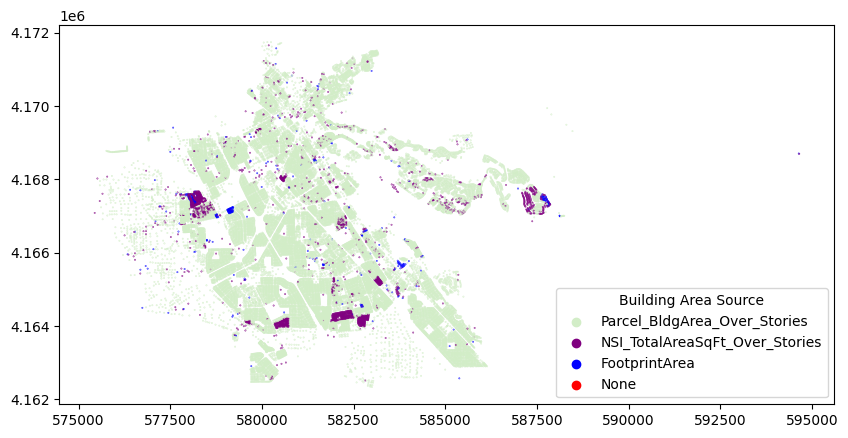

In [19]:
## SELECT SOURCE FOR PLAN AREA ##

# Remove cases in tax data where building area is zero 
inv_mod.loc[inv_mod[inv_mod['Parcel_BldgArea_Single'] == 0].index, 'Parcel_BldgArea_Single'] = np.nan
inv_mod.loc[inv_mod[inv_mod['NSI_TotalAreaSqFt_Single'] == 0].index, 'NSI_TotalAreaSqFt_Single'] = np.nan
inv_mod.loc[inv_mod[inv_mod['FootprintArea'] == 0].index, 'FootprintArea'] = np.nan

# Modify all RES2 strucutres in tax data to have one story 
inv_mod.loc[inv_mod[inv_mod['Address_FeatureCode_Hazus_Single'] == 'RES2'].index, 'Parcel_NumStories_Single'] = 1

inv_mod['PlanArea_Best'] = inv_mod.apply(
    lambda row: (row['Parcel_BldgArea_Single'] / row['Parcel_NumStories_Single']) if (pd.notna(row['Parcel_BldgArea_Single']) and pd.notna(row['Parcel_NumStories_Single']))
    else ((row['NSI_TotalAreaSqFt_Single'] / row['NSI_NumberOfStories_Single']) if (pd.notna(row['NSI_TotalAreaSqFt_Single']) and pd.notna(row['NSI_NumberOfStories_Single']))
    else (row['FootprintArea'] if pd.notna(row['FootprintArea']) 
    else np.nan)), axis=1)

inv_mod['PlanArea_Best_Source'] = inv_mod.apply(
    lambda row: 'Parcel_BldgArea_Over_Stories' if (pd.notna(row['Parcel_BldgArea_Single']) and pd.notna(row['Parcel_NumStories_Single']))
    else ('NSI_TotalAreaSqFt_Over_Stories' if (pd.notna(row['NSI_TotalAreaSqFt_Single']) and pd.notna(row['NSI_NumberOfStories_Single']))
    else ('FootprintArea' if pd.notna(row['FootprintArea']) 
    else ('None'))), axis=1)



## PLOT INFORMATION SOURCE 
if plot_sources: 
    
    # Filter only for footprints with local data 
    inv_mod2 = inv_mod[~((inv_mod['Local_Flag']==0))].copy()

    # Define a color map for given field 
    unique_values = ['Parcel_BldgArea_Over_Stories', 'NSI_TotalAreaSqFt_Over_Stories', 'FootprintArea', 'None']
    color_map = {value: color for value, color in zip(unique_values, ['#d2edc7', 'purple', 'blue', 'red'])}
    inv_mod2['color'] = inv_mod2['PlanArea_Best_Source'].map(color_map)

    # Plot
    fig, ax = plt.subplots(figsize=(10, 8))
    inv_mod2.plot(ax=ax, color=inv_mod2['color'], markersize = .1)
    for value, color in color_map.items():
        ax.scatter([], [], color=color, label=value)
    ax.legend(title='Building Area Source') 
    plt.show()


#### OCCUPANCY CLASS

Occupancy Class Priority List: 

1. Designate all RES1 cases where NSI, address, and parcel boths ay RES1 
2. HIFLD Points
2. Address Feature Code (seems to be reliable based on spot checking and specificity to given unit, rather than a parcel, which may contain multiple footprints)
3. Tax Use Description 
3. NSI


In [20]:
## CLEAN CASES BASED ON NOTBLDG, UNK, AND _VAC TAX DATA 
print(len(inv_mod))
inv_mod = resolve.clean_supplemental_occ(inv_mod.copy())
print(len(inv_mod))

38587
38587


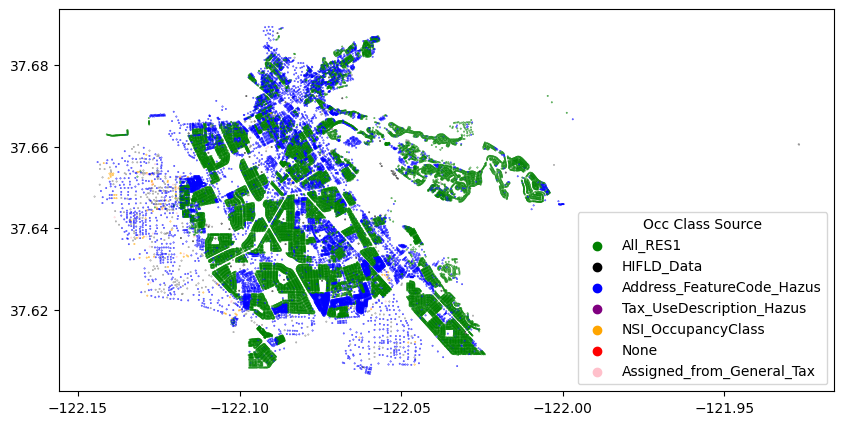

In [28]:
# Pre-set tracking column to None
inv_mod['OccupancyClass_Best_Source'] = 'None'

# For cases with all three sources calling it a RES1, label as RES1 and reset number of units to 1
all_res1 = inv_mod[(inv_mod['NSI_OccupancyClass_Single'] == inv_mod['Address_FeatureCode_Hazus_Single']) & (inv_mod['NSI_OccupancyClass_Single'] == inv_mod['Parcel_UseDescription_Hazus_Single']) & (inv_mod['NSI_OccupancyClass_Single'] == 'RES1')]
inv_mod.loc[all_res1.index,'OccupancyClass_Best'] = inv_mod.loc[all_res1.index,'Address_FeatureCode_Hazus_Single'].values
inv_mod.loc[all_res1.index,'OccupancyClass_Best_Source'] = 'All_RES1'
inv_mod.loc[all_res1.index,'Units_Best'] = 1
inv_mod.loc[all_res1.index,'Units_Best_Source'] = 'Updated_by_OccClass'

# Prioiritize HIFLD Data over other sources 
hifld = inv_mod[inv_mod['POINT_Source_national'].apply(lambda x: x == 'HIFLD' or ('HIFLD' in x if isinstance(x, list) else False))]
inv_mod.loc[hifld.index,'OccupancyClass_Best'] = hifld['NSI_OccupancyClass_Single']
inv_mod.loc[hifld.index,'OccupancyClass_Best_Source'] = 'HIFLD_Data'

# Assign occupancy class to generic assignments for cases without NSI data
inv_mod = resolve.assign_generic_tax_missing(inv_mod, ['IND',''], [1, 2, 3, 4, 5, 6]) # Extra '' here means that empty things get assigned randomly as industrial
inv_mod = resolve.assign_generic_tax_missing(inv_mod, ['COM'], [1, 2, 3, 4, 5, 7, 8, 9, 10]) # Not including hospitals as an option 
inv_mod = resolve.assign_generic_tax_missing(inv_mod, ['RES'], [3]) # Only including multifamily residential 

# For cases with generic (IND, COM, RES) tax occupancy, assign NSI data as occupancy class 
generic_tax_with_nsi = inv_mod[
    (inv_mod['Address_FeatureCode_Hazus_Single'].isin(['IND','COM','RES'])) & # Address occupancy is generic
    (inv_mod['Parcel_UseDescription_Hazus_Single'].isin(['IND','COM','RES'])) &  # Parcel occupancy is generic
    (inv_mod['NSI_OccupancyClass_Single'] != '')]                  # NSI is not missing
inv_mod.loc[generic_tax_with_nsi.index, 'OccupancyClass_Best'] = inv_mod.loc[generic_tax_with_nsi.index, 'NSI_OccupancyClass_Single']
inv_mod.loc[generic_tax_with_nsi.index, 'OccupancyClass_Best_Source'] = 'NSI_OccupancyClass'

# Drop uncertain and NOTBLDG titles and find remaining
remaining = inv_mod[inv_mod['OccupancyClass_Best_Source']=='None']
remaining.loc[remaining[remaining['Address_FeatureCode_Hazus_Single'].isin(['IND', 'COM', 'RES'])].index, 'Address_FeatureCode_Hazus_Single'] = ''
remaining.loc[remaining[remaining['Parcel_UseDescription_Hazus_Single'].isin(['IND', 'COM', 'RES'])].index, 'Parcel_UseDescription_Hazus_Single'] = ''

# Update using prioritization
inv_mod.loc[remaining.index, 'OccupancyClass_Best'] = remaining.apply(
    lambda row: row['Address_FeatureCode_Hazus_Single'] if (row['Address_FeatureCode_Hazus_Single']!='') 
    else (row['Parcel_UseDescription_Hazus_Single'] if (row['Parcel_UseDescription_Hazus_Single']!='') 
    else (row['NSI_OccupancyClass_Single'] if (row['NSI_OccupancyClass_Single']!='') 
    else np.nan)), axis=1)

inv_mod.loc[remaining.index,'OccupancyClass_Best_Source'] = remaining.apply(
    lambda row: 'Address_FeatureCode_Hazus' if (row['Address_FeatureCode_Hazus_Single']!='') 
    else ('Parcel_UseDescription_Hazus' if (row['Parcel_UseDescription_Hazus_Single']!='') 
    else ('NSI_OccupancyClass' if (row['NSI_OccupancyClass_Single']!='') 
    else ('None'))), axis=1)

# Update occupancy class based on best estimate of number of units 
inv_mod['OccupancyClass_Best'] = inv_mod['OccupancyClass_Best'].fillna('')
inv_mod['OccupancyClass_Best'] = inv_mod.apply(resolve.update_res_occ, axis=1)


## PLOT INFORMATION SOURCE 
if plot_sources: 
    
    # Filter only for footprints with local data 
    inv_mod2 = inv_mod[~((inv_mod['Local_Flag']==0))].copy()

    # Define a color map for given field 
    unique_values = ['All_RES1', 'HIFLD_Data', 'Address_FeatureCode_Hazus', 'Tax_UseDescription_Hazus', 'NSI_OccupancyClass', 'None','Assigned_from_General_Tax']
    color_map = {value: color for value, color in zip(unique_values, ['green', 'black', 'blue', 'purple', 'orange', 'red','pink'])}
    inv_mod2['color'] = inv_mod2['OccupancyClass_Best_Source'].map(color_map).fillna('gray')

    # Plot
    fig, ax = plt.subplots(figsize=(10, 8))
    inv_mod2.to_crs('EPSG:4326').plot(ax=ax, color=inv_mod2['color'], markersize = .1)
    for value, color in color_map.items():
        ax.scatter([], [], color=color, label=value)
    ax.legend(title='Occ Class Source') 
    plt.show()



In [ ]:
## MORE DETAILED PLOTTING OF OCCUPANCY CLASS 

# Filter for values with data
inv_mod2 = inv_mod[~((inv_mod['National_Flag']==0) & (inv_mod['Local_Flag']==0))]

# Merge with footprints 
new = inv_mod2[['OccupancyClass_Best_Source', 'OccupancyClass_Best','FootprintID']].merge(footprints[['FootprintID','geometry']], on = 'FootprintID')

# Convert to gdf
new = gpd.GeoDataFrame(new, geometry = 'geometry', crs = f'EPSG:{crs_main}')
new = new.to_crs(crs_plot)

# Define a color map based on the unique values in your column
unique_values = ['All_RES1', 'HIFLD_Data', 'Address_FeatureCode_Hazus', 'Parcel_UseDescription_Hazus', 'NSI_OccupancyClass', 'None','Assigned_from_General_Tax']
color_map = {value: color for value, color in zip(unique_values, ["#a7a7d6ff", "black", "#a7a7d6ff" ,"#034185", "#a14059", "#ace1fbff", "gray"])} # Old RES 1 277b8eff


# Map colors to the column values
new['color'] = new['OccupancyClass_Best_Source'].map(color_map)


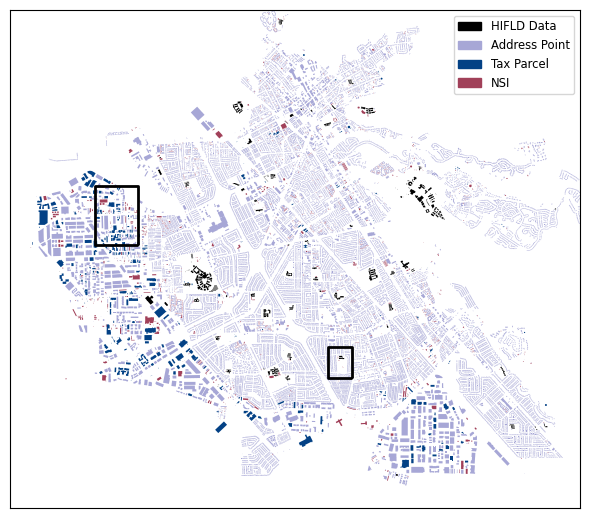

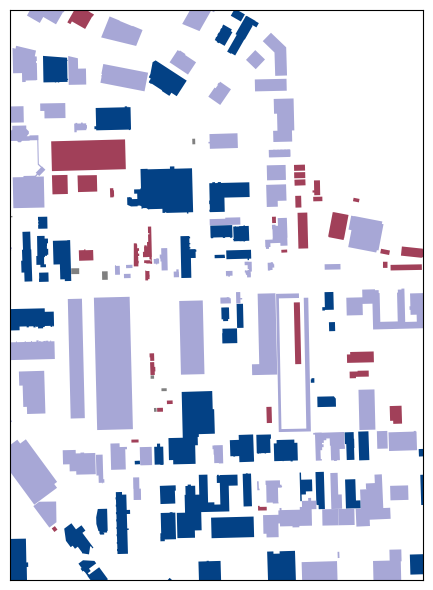

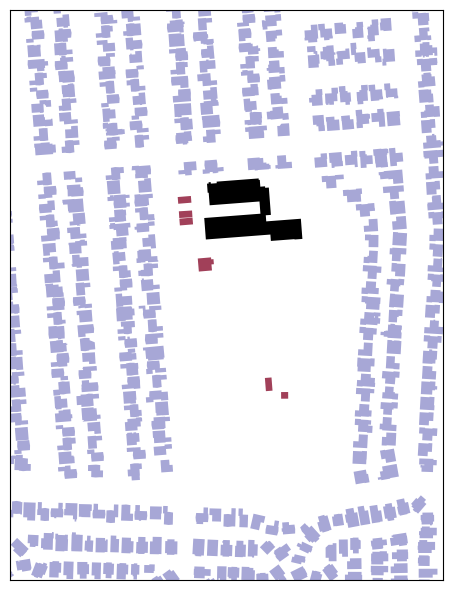

In [32]:
## MORE DETAILED PLOTTING OF OCCUPANCY CLASS 

# Filter for values with data
inv_mod2 = inv_mod[~((inv_mod['National_Flag']==0) & (inv_mod['Local_Flag']==0))]

# Merge with footprints 
new = inv_mod2[['OccupancyClass_Best_Source', 'OccupancyClass_Best','FootprintID']].merge(footprints[['FootprintID','geometry']], on = 'FootprintID')

# Convert to gdf
new = gpd.GeoDataFrame(new, geometry = 'geometry', crs = f'EPSG:{crs_main}')
new = new.to_crs(crs_plot)

# Define a color map based on the unique values in your column
unique_values = ['All_RES1', 'HIFLD_Data', 'Address_FeatureCode_Hazus', 'Parcel_UseDescription_Hazus', 'NSI_OccupancyClass', 'None','Assigned_from_General_Tax']
color_map = {value: color for value, color in zip(unique_values, ["#a7a7d6ff", "black", "#a7a7d6ff" ,"#034185", "#a14059", "#ace1fbff", "gray"])} # Old RES 1 277b8eff

# Map colors to the column values
new['color'] = new['OccupancyClass_Best_Source'].map(color_map)


### SELECT WHICH BOX TO PLOT 

# Industrial 
bb1 = box(-122.130508,37.647503,-122.120742,37.658173)

# Another school
bb2 = box(-122.0773938389,37.6235564984,-122.0720238049,37.6291561748)

bb_list = [bb1, bb2]

## PLOT OVERALL
fig, ax = plt.subplots(1, 1, figsize=(6,6))
new.plot(ax=ax,color=new['color'], markersize = 10)
ax.set_xlim(xbounds)
ax.set_ylim(ybounds)
# ctx.add_basemap(ax, crs='EPSG:4326', source=ctx.providers.CartoDB.PositronNoLabels, zoom=13)

for bb in bb_list:
    gdf_bb = gpd.GeoDataFrame({"geometry": [bb]}, crs=crs_plot)
    gdf_bb.boundary.plot(ax=ax, edgecolor="black", linewidth=2, alpha = 1)
ax.xaxis.set_major_formatter(ScalarFormatter(useOffset=False))
ax.yaxis.set_major_formatter(ScalarFormatter(useOffset=False))
ax.xaxis.set_major_locator(MaxNLocator(nbins=7))  # Adjust `nbins` as needed for fewer ticks
ax.set_xticks([])  # Remove x-axis ticks
ax.set_yticks([])  # Remove y-axis ticks
ax.set_xticklabels([])  # Remove x-axis labels
ax.set_yticklabels([])  # Remove y-axis labels

# Add legend
stanford_palette = [
    "#034185", 
    "#a14059",  
    "#277b8eff",  
    "#ace1fbff",    
    "#a7a7d6ff"]

# Add a legend
legend_patches = [mpatches.Patch(color='black', label='HIFLD Data'),
    mpatches.Patch(color='#a7a7d6ff', label='Address Point'),
    mpatches.Patch(color='#034185', label='Tax Parcel'),
    mpatches.Patch(color='#a14059', label='NSI'),]

plt.legend(handles=legend_patches, loc='upper right', fontsize = 'small')
plt.tight_layout()
plt.savefig(fig_dir + f"prioritization_overview.svg", format="svg",  bbox_inches='tight', pad_inches=0)
plt.savefig(fig_dir + f"prioritization.png", bbox_inches='tight', pad_inches=0, dpi = 500)
# plt.close()

counter = 0 
## PLOT FIRST BOX 
for bb in bb_list:
    fig, ax = plt.subplots(1, 1, figsize=(6,6))
    bb_coords = list(bb.exterior.coords)
    trim_new = new[new.geometry.intersects(bb)]
    trim_new.plot(ax=ax,color=trim_new['color'], markersize = 10)
    # ctx.add_basemap(ax, crs='EPSG:4326', source=ctx.providers.CartoDB.PositronNoLabels)
    gdf_bb = gpd.GeoDataFrame({"geometry": [bb]}, crs=crs_plot)
    gdf_bb.boundary.plot(ax=ax, edgecolor="red", linewidth=2, alpha = 0)
    plt.xlim([bb_coords[2][0], bb_coords[0][0]])
    plt.ylim([bb_coords[0][1], bb_coords[2][1]])
    ax.xaxis.set_major_formatter(ScalarFormatter(useOffset=False))
    ax.yaxis.set_major_formatter(ScalarFormatter(useOffset=False))
    ax.xaxis.set_major_locator(MaxNLocator(nbins=7))  # Adjust `nbins` as needed for fewer ticks
    ax.set_xticks([])  # Remove x-axis ticks
    ax.set_yticks([])  # Remove y-axis ticks
    ax.set_xticklabels([])  # Remove x-axis labels
    ax.set_yticklabels([])  # Remove y-axis labels


    plt.tight_layout()
    plt.savefig(fig_dir + f"prioritization{counter}.svg", format="svg",  bbox_inches='tight', pad_inches=0)
    plt.savefig(fig_dir + f"prioritization{counter}.png", bbox_inches='tight', pad_inches=0, dpi = 500)
    counter += 1
    # plt.close()

#### BUILDING TYPE

Building Type Priority List: 

1. All RES2 buildings designated as building type H, regardless of data
2. Remove cases where tax data specifies steel and concrete in RES1, RES3A, RES3B -- this is likely incorrect (very few of these points) 
2. Tax construction designation from parcel data 
3. NSI data is NOT used. If tax data not available, structure type is sampled within specifying building type

In [33]:

# For all buildings with best estimate of occupancy as RES2, reset to type H
inv_mod.loc[inv_mod[inv_mod['OccupancyClass_Best']=='RES2'].index, 'NSI_BuildingType'] = 'H'
inv_mod.loc[inv_mod[inv_mod['OccupancyClass_Best']=='RES2'].index, 'Parcel_Construction_Single'] = 'H'

# For all buildings with best estimate of occupancy as RES2, reset to 1 story - very small number are equal to 2, vast majority are 1 or missing 
inv_mod.loc[inv_mod[inv_mod['OccupancyClass_Best']=='RES2'].index, 'Stories_Best'] = 1

# For RES1, RES3A, and RES3B, if a structure is listed as steel or concrete, reset to np.nan - this is likely incorrect 
inv_mod.loc[inv_mod[(inv_mod['OccupancyClass_Best'].isin(['RES1','RES3A','RES3B'])) & (inv_mod['Parcel_Construction_Single'].isin(['S', 'C']))].index, 'Parcel_Construction_Single'] = np.nan


/Users/mialochhead/Documents/GitHub/Building_Inventory_Generation/inventory_env/lib/python3.10/site-packages/geopandas/geodataframe.py:1819: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  super().__setitem__(key, value)
/Users/mialochhead/Documents/GitHub/Building_Inventory_Generation/inventory_env/lib/python3.10/site-packages/geopandas/geodataframe.py:1819: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  super().__setitem__(key, value)


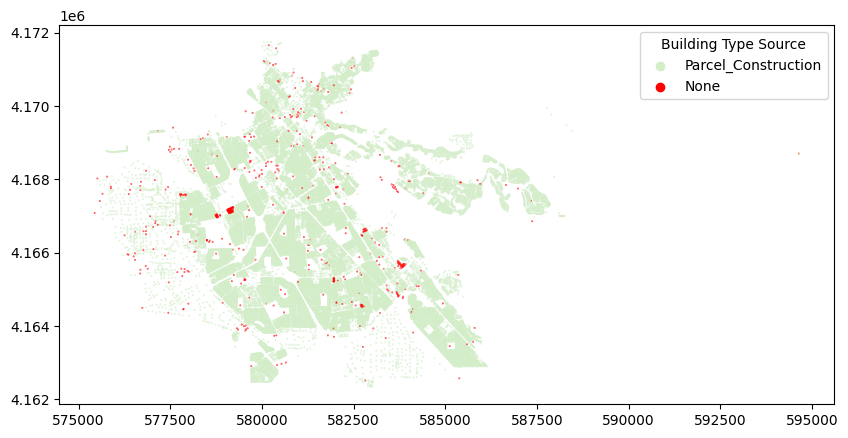

In [39]:
## PRIORITIZE DATA FOR BUILDING TYPE ##

# Create combined row with best estimate of year built 
inv_mod['BuildingType_Best'] = inv_mod.apply(
    lambda row: row['Parcel_Construction_Single'] if pd.notna(row['Parcel_Construction_Single']) 
    else (np.nan), axis=1)

# Create combined row with source of best estimate year 
inv_mod['BuildingType_Best_Source'] = inv_mod.apply(
    lambda row: 'Parcel_Construction' if pd.notna(row['Parcel_Construction_Single']) 
        else ('None'), axis=1)



## PLOT INFORMATION SOURCE 
if plot_sources: 
    
    # Filter only for footprints with local data 
    inv_mod2 = inv_mod[~((inv_mod['Local_Flag']==0))].copy()

    # Define a color map for given field 
    unique_values = ['Parcel_Construction', 'None']
    color_map = {value: color for value, color in zip(unique_values, ['#d2edc7', 'red'])}
    inv_mod2['color'] = inv_mod2['BuildingType_Best_Source'].map(color_map)

    # Plot
    fig, ax = plt.subplots(figsize=(10, 8))
    inv_mod2.plot(ax=ax, color=inv_mod2['color'], markersize = .1)
    for value, color in color_map.items():
        ax.scatter([], [], color=color, label=value)
    ax.legend(title='Building Type Source') 
    plt.show()


#### REPLACEMENT COST USING HAZUS

Replacement Cost Priority List: 

1. Replacement Cost from summing NSI value present across points (NSI_ReplacementCost)
2. Replacement Cost from multiplying occupancy-specific HAZUS values by total square footage (ReplacementCost_Hazus)

In [34]:
# Load Hazus cost values 
hazus_conversion = pd.read_csv('./Input_Data/National/Hazus_Cost.csv')

# Compute hazus replacement cost
inv_mod = resolve.compute_hazus_replacement_cost(inv_mod.copy(), hazus_conversion)

0 points with NSI replacement cost values larger than the largest Hazus computed value - NSI cost dropped


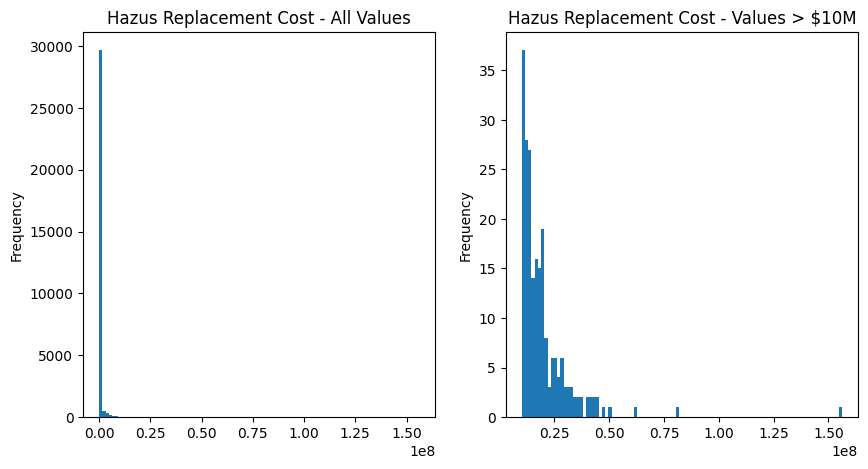

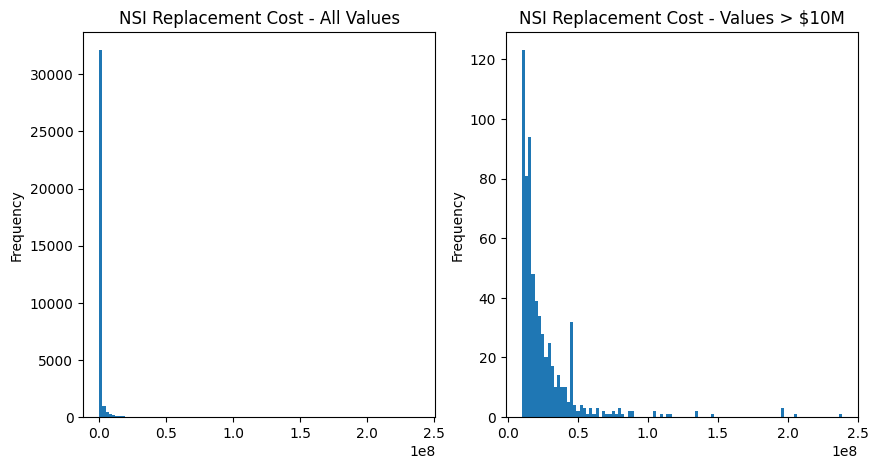

In [35]:
# Check replacement cost for unreasonable values -- Hauzs Replacement Cost
fig, ax = plt.subplots(1,2, figsize=(10, 5)) 
inv_mod['ReplacementCost_Hazus'].plot.hist(ax=ax[0], bins=100)
inv_mod[inv_mod['ReplacementCost_Hazus'] > 1E7]['ReplacementCost_Hazus'].plot.hist(ax=ax[1], bins=100)
ax[0].set_title('Hazus Replacement Cost - All Values')
ax[1].set_title('Hazus Replacement Cost - Values > $10M')

# Check replacement cost for unreasonable values -- NSI Replacement Cost
fig, ax = plt.subplots(1,2, figsize=(10, 5)) 
inv_mod['NSI_ReplacementCost'].plot.hist(ax=ax[0], bins=100)
inv_mod[inv_mod['NSI_ReplacementCost'] > 1E7]['NSI_ReplacementCost'].plot.hist(ax=ax[1], bins=100)
ax[0].set_title('NSI Replacement Cost - All Values')
ax[1].set_title('NSI Replacement Cost - Values > $10M')

# In case of Hayward, replace Hazus computed values larger than the max of NSI replacement costs with median of given occupancy class
# This limit was used in Hayward because of the presence of some unreasonabley large values, and should be further explored 
highcost = inv_mod[inv_mod['ReplacementCost_Hazus']>max(inv_mod['NSI_ReplacementCost'])]
for idx, row in highcost.iterrows():
    occ = row['OccupancyClass_Best']
    inv_mod.loc[idx, 'ReplacementCost_Hazus'] = np.median(inv_mod[inv_mod['OccupancyClass_Best']==occ]['ReplacementCost_Hazus'])
print(len(highcost), 'points with NSI replacement cost values larger than the largest Hazus computed value - NSI cost dropped')

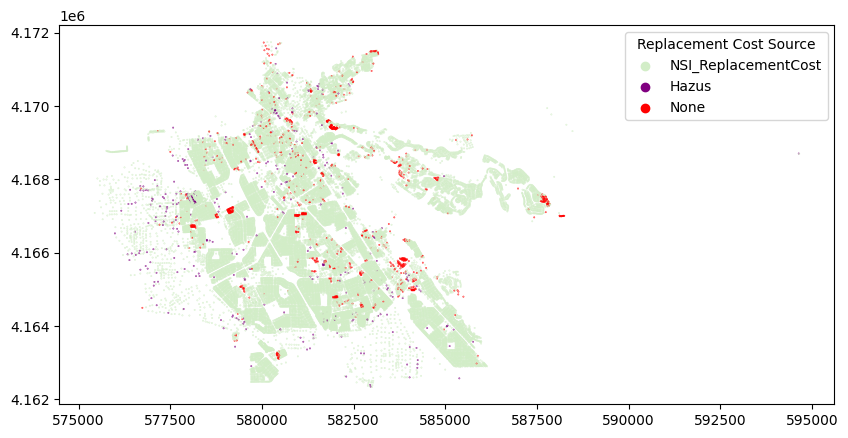

In [36]:
## PRIORITIZE SOURCES FOR REPLACEMENT COST ##

# Remove cases where NSI value is listed as 0
inv_mod.loc[inv_mod[inv_mod['NSI_ReplacementCost'] == 0].index, 'NSI_ReplacementCost'] = np.nan

# Prioritize NSI Replacement Cost, then Hazus-computed replacement cost
inv_mod['ReplacementCost_Best'] = inv_mod.apply(
    lambda row: row['NSI_ReplacementCost'] if pd.notna(row['NSI_ReplacementCost']) 
    else (row['ReplacementCost_Hazus'] if pd.notna(row['ReplacementCost_Hazus']) 
    else (np.nan)), axis=1)

inv_mod['ReplacementCost_Best_Source'] = inv_mod.apply(
    lambda row: 'NSI_ReplacementCost' if pd.notna(row['NSI_ReplacementCost']) 
    else ('Hazus' if pd.notna(row['ReplacementCost_Hazus']) 
    else ('None')), axis=1)



## PLOT INFORMATION SOURCE 
if plot_sources: 
    
    # Filter only for footprints with local data 
    inv_mod2 = inv_mod[~((inv_mod['Local_Flag']==0))].copy()

    # Define a color map for given field 
    unique_values = ['NSI_ReplacementCost', 'Hazus', 'None']
    color_map = {value: color for value, color in zip(unique_values, ['#d2edc7', 'purple', 'red'])}
    inv_mod2['color'] = inv_mod2['ReplacementCost_Best_Source'].map(color_map)

    # Plot
    fig, ax = plt.subplots(figsize=(10, 8))
    inv_mod2.plot(ax=ax, color=inv_mod2['color'], markersize = .1)
    for value, color in color_map.items():
        ax.scatter([], [], color=color, label=value)
    ax.legend(title='Replacement Cost Source') 
    plt.show()


### **Export**

In [37]:
# Export Inventory
fxns.gdf_to_json(inv_mod, dir_generation + 'Inventory_AllFields.json')

JSON File Saved


## **Prepare File for Imputation**

In [40]:
# Load best estimate inventory 
data = fxns.json_to_gdf(dir_generation + 'Inventory_AllFields.json', crs_main)

# Remove cases of footprints with no data
data = data[data['Remove_Footprint_Flag'] == 0]
data = data[~((data['National_Flag']==0) & (data['Local_Flag']==0))]
print(len(data))

# Convert to format of R2D - keep missing data (for imputation purposes)
for_imputation = data.copy().to_crs(crs_plot)
for_imputation['Longitude'] = for_imputation['geometry'].x
for_imputation['Latitude'] = for_imputation['geometry'].y

# Separate required columns for imputation 
for_imputation = for_imputation[['Latitude','Longitude','PlanArea_Best','Stories_Best','Year_Best','ReplacementCost_Best','ReplacementCost_Hazus','OccupancyClass_Best', 'BuildingType_Best','Units_Best','NSI_Population_Night','CensusBlock','CensusTract','FootprintID']]

# Standardize columns for imputation and R2D 
for_imputation = for_imputation.rename(columns={
    'PlanArea_Best' : 'PlanArea',
    'Stories_Best': 'NumberOfStories',
    'Year_Best': 'YearBuilt',
    'OccupancyClass_Best': 'OccupancyClass',
    'BuildingType_Best':'BuildingType',
    'ReplacementCost_Best':'ReplacementCost',
    'NSI_Population_Night':'NightPopulation',
    'Units_Best':'NumberOfUnits'})

## ASSUMPTION: FOR NOW, ALL 1.5 STORY BUILDINGS ARE 2 STORY, ALL 2.5 STORY BUILDINGS ARE 3 STORIES
for_imputation.loc[for_imputation[for_imputation['NumberOfStories']==1.5].index, 'NumberOfStories']=2
for_imputation.loc[for_imputation[for_imputation['NumberOfStories']==2.5].index, 'NumberOfStories']=3

# Convert None for imputation types 
for_imputation['BuildingType'] = for_imputation['BuildingType'].replace('None', np.nan)

# Add index
for_imputation.insert(0, 'index', range(len(for_imputation)))

# Export inventory 
for_imputation.to_csv(dir_generation + 'Inventory_Before_Imputation.csv', index = False)

34959


KeyError: "['BuildingType_Best'] not in index"

## **Impute Data**

In [ ]:
# Specify data for imputation
file_path = directory + 'InventoryGeneration/Inventory_Before_Imputation.csv'

# create an Import to get the classes
importer = Importer()
knn_imputer_class = importer.get_class("KnnImputer")

# Load inventory 
inventory = AssetInventory()
inventory.read_from_csv(file_path,keep_existing=True, id_column='index') 

# # Print example of assets 
# inventory.get_asset_features(86)[1]  # empty or 'NA' are missing values
# # First number is building index, [1] narrows down to just data 

No existing inventory found. Reading in the new inventory from the file.


True

In [ ]:
# Imput data
imputer=knn_imputer_class(inventory,n_possible_worlds=1, exclude_features=['PlanArea','ReplacementCost','NightPopulation','OccupancyClass','FootprintID','BuildingType'])
new_inventory = imputer.impute()

# print('\n\nExample Imptued Row Output')
# new_inventory.get_asset_features(86)[1]  # empty or 'NA' are missing values

/Users/mialochhead/Documents/GitHub/Building_Inventory_Generation/inventory_env/lib/python3.10/site-packages/brails/imputers/knn_imputer/knn_imputer.py:158: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  bldg_properties_df = bldg_properties_df.replace("", np.nan, inplace=False)


Missing percentages among 34959 assets
NumberOfStories: 0.59%
YearBuilt: 0.85%
Primitive imputation done.
Running the main imputation. This may take a while.
Enumerating clusters: 20 among 70
Enumerating clusters: 40 among 70
Enumerating clusters: 60 among 70
Done imputation. It took 0.00 mins


In [ ]:
# Conver to pandas geodataframe
inv_geoj = new_inventory.get_geojson()
gdf = gpd.GeoDataFrame.from_features(inv_geoj["features"])

# Correct data type for population
gdf['NightPopulation'] = gdf['NightPopulation'].replace('',0)

## SAVE IMPUTED INVENTORY
fxns.gdf_to_json(gdf, directory + 'InventoryGeneration/Inventory_IMPUTED.json')


/var/folders/h5/xf79vsp167q_tf4t38sfv58c0000gn/T/ipykernel_21695/110169863.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  gdf['NightPopulation'] = gdf['NightPopulation'].replace('',0)


JSON File Saved


## **Infer Structure Type**

In [42]:
# Load inventory 
data = fxns.json_to_gdf(dir_generation + 'Inventory_IMPUTED.json', crs_main)

In [ ]:
# SET FLAGS
use_bldg_type = True # Use building type (material) to constrain list of possible structure types  
allow_mh_only_for_res2 = True # Allows structure type 'MH' only when the occupancy class is RES2 (diverges from Hazus) 
no_urm = True # Doesn't allow the assignment of URM buildings, due to efforts to retrofit those buildings (diverges from Hazus)
res3ab_to_res1_flag = True # Adopts structure types used for 'RES1' to be assigned for RES3A and RES3B. 2-4 unit structures are likely structurally more similar to single family homes than to large apartment buildings. 


# SET VARIABLE NAMES
occ_key = 'OccupancyClass'
nstory_key = 'NumberOfStories'
year_key = 'YearBuilt'
strtype_key = 'StructureType'
bldgtype_key = 'BuildingType'
n_pw = 1

# CALL FUNCTION TO INFER STRUCTURE TYPE
bldg_properties_df = resolve.infer_structure_type(data.copy(), state, occ_key, nstory_key, year_key, bldgtype_key, strtype_key, n_pw, use_bldg_type, allow_mh_only_for_res2, no_urm, res3ab_to_res1_flag)


## REPEAT IMPUTATION PROCESS AND REMOVE BUILDING TYPES THAT ARE MISSING HAZUS FRAGILITY FUNCTIONS 
alldata = bldg_properties_df.copy()
missing_structuretype = alldata[((alldata['StructureType'].isna()) | (alldata['StructureType']=='na'))].copy()
has_structuretype = alldata[~((alldata['StructureType'].isna()) | (alldata['StructureType']=='na'))].copy()

# Check if any data lost
if len(missing_structuretype) + len(has_structuretype) != len(alldata):
    raise ValueError('Data Lost')

# SET FLAGS
use_bldg_type = False # Use building type (material) to constrain list of possible structure types  
allow_mh_only_for_res2 = True # Allows structure type 'MH' only when the occupancy class is RES2 (diverges from Hazus) 
no_urm = True # Doesn't allow the assignment of URM buildings, due to efforts to retrofit those buildings (diverges from Hazus)
res3ab_to_res1_flag = True # Adopts structure types used for 'RES1' to be assigned for RES3A and RES3B. 2-4 unit structures are likely structurally more similar to single family homes than to large apartment buildings. 

# CALL FUNCTION TO INFER STRUCTURE TYPE
bldg_properties_df = resolve.infer_structure_type(missing_structuretype.copy(), state, occ_key, nstory_key, year_key, bldgtype_key, strtype_key, n_pw, use_bldg_type, allow_mh_only_for_res2, no_urm, res3ab_to_res1_flag)

# Recombine dataframes 
recombined_gdf = gpd.GeoDataFrame(pd.concat([has_structuretype, bldg_properties_df], ignore_index=True))

# Check if any data lost
if len(recombined_gdf) != len(alldata):
    raise ValueError('Data Lost')

# EXPORT
inv_natl.gdf_to_json(recombined_gdf, dir_generation + 'Inventory_IMPUTED_With_StructureType.json')

CHECK: Regions considered in structure type assignment: ['West Coast']
HAZUS does not provide structural type information for West Coast-RES2-low_rise-1950_to_1970-W
Num Buildings in that Class: 1
HAZUS does not provide structural type information for West Coast-IND3-low_rise-1950_to_1970-W
Num Buildings in that Class: 1
HAZUS does not provide structural type information for West Coast-RES3-mid_rise-1950_to_1970-W
Num Buildings in that Class: 3
HAZUS does not provide structural type information for West Coast-RES3-mid_rise-post_1970-W
Num Buildings in that Class: 20
HAZUS does not provide structural type information for West Coast-COM1-mid_rise-post_1970-W
Num Buildings in that Class: 1
HAZUS does not provide structural type information for West Coast-COM1-high_rise-1950_to_1970-S
Num Buildings in that Class: 1
HAZUS does not provide structural type information for West Coast-COM1-high_rise-post_1970-S
Num Buildings in that Class: 1
HAZUS does not provide structural type information fo

## **Export for R2D**

In [ ]:
# Convert to format of R2D - remove missing data (for test run only)
bldg_properties_df_nomissing = recombined_gdf[~((recombined_gdf['StructureType'].isna()) | (recombined_gdf['StructureType']=='na'))].copy()
print(len(recombined_gdf[((recombined_gdf['StructureType'].isna()) | (recombined_gdf['StructureType']=='na'))].copy()), 'points dropped due to missing structure type')

# Create appropriate columns
r2d = bldg_properties_df_nomissing.copy()
r2d['Longitude'] = r2d['geometry'].x
r2d['Latitude'] = r2d['geometry'].y
r2d = r2d[['Latitude','Longitude','PlanArea','NumberOfStories','YearBuilt','ReplacementCost','ReplacementCost_Hazus','StructureType','BuildingType','OccupancyClass_clean','OccupancyClass','NumberOfUnits','NightPopulation','CensusBlock','CensusTract','FootprintID','geometry']]

# Assign design level and height class (used in regional analysis)
r2d = resolve.find_design_level(r2d, 'StructureType', 'YearBuilt', 'DesignLevel')
r2d = resolve.find_height_class(r2d, 'StructureType', 'NumberOfStories', 'HeightClass')

# Add id
r2d.insert(0, 'id', range(len(r2d)))

# Rename occupancy class columns for R2D use
r2d = r2d.rename(columns={'OccupancyClass': 'OccupancyClass_Actual',
                          'OccupancyClass_clean': 'OccupancyClass'})

# Save inventory
r2d.to_csv(dir_r2d + 'R2D_Inventory.csv', index = False)
fxns.gdf_to_json(r2d, dir_r2d + 'R2D_Inventory.json')

# Randomly sample for R2D test run 
sampled_df = r2d.sample(n=50, random_state=1, replace = False)
sampled_df = sampled_df.drop(columns='id')
sampled_df.insert(0, 'id', range(len(sampled_df)))
sampled_df.to_csv(dir_r2d + 'R2D_Inventory_SAMPLED.csv', index = False)

3 points dropped due to missing structure type
JSON File Saved


In [ ]:
# #### UNCOMMENT TO CHECK FOR GAPS IN R2D INVENTORY
# # Only BuildingType or HeightClass should possibly have missing data

# for col in r2d.columns: 
#     print(col)
    
#     if len(r2d[r2d[col].isna()]) > 0:
#         print('\n\nDATA WITH ISNA:', col, len(r2d[r2d[col].isna()]),'\n\n')
#     if len(r2d[r2d[col]=='']) > 0:
#         print('\n\nDATA WITH "":',col, len(r2d[r2d[col]=='']),'\n\n')
#     if len(r2d[r2d[col]=='None']) > 0:
#         print('\n\nDATA WITH None:',col, len(r2d[r2d[col]=='']),'\n\n')
#     if len(r2d[r2d[col]=='na']) > 0:
#         print('\n\nDATA WITH na:',col, len(r2d[r2d[col]=='']),'\n\n')


In [ ]:
# ### CODE TO CLEAN RES1 FIELDS SLIGHTLY FOR ANNA ELISA -- NOT RELEVANT IN OTHER CONTEXTS 

# # Load best estimate inventory 
# data = inv_natl.json_to_gdf(dir_generation + 'Inventory_AllFields.json', crs_main)

# # Remove cases of footprints with no data
# data = data[data['Remove_Footprint_Flag'] == 0]
# data = data[~((data['National_Flag']==0) & (data['Local_Flag']==0))]


# # Convert data to list values for ease of use 
# column = 'NSI_OccupancyClass'
# data[column] = data[column].apply(inv_natl.convert_to_list)

# def normalize_res1(lst):
#     if isinstance(lst, list):
#         return ['RES1' if isinstance(item, str) and 'RES1' in item else item for item in lst]
#     return lst

# data[column] = data[column].apply(normalize_res1)

# # Export Inventory
# inv_natl.gdf_to_json(data, dir_generation + 'Inventory_AllFields_CleanRES1.json')
